# Netflix Movies & TV Shows — Content Strategy Analysis

## Business Problem / Problema de Negocio
As streaming platforms compete globally, content investment decisions require data.
**Key question: Which countries, genres, and ratings dominate Netflix — and what does that mean for content strategy?**

A medida que las plataformas compiten globalmente, las decisiones de inversión requieren datos.
**Pregunta clave: ¿Qué países, géneros y clasificaciones dominan Netflix — y qué implica eso para la estrategia de contenido?**

## Dataset
- **Source:** Kaggle — Netflix Movies and TV Shows (regularly updated)
- **Variables:** title, type, country, director, cast, rating, release_year, duration, listed_in
- **Size:** ~8,800 titles

## Tools / Herramientas
Python · Pandas · Matplotlib · Seaborn · Google Looker Studio7

In [2]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


In [5]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for kaggle: filename=kaggle-1.6.17-py3-none-any.whl size=105797 sha256=48fde0e1b2210c384d1bd692a634de50ea458e9d2256c15b21567cb9e8ea9fce
  Stored in directory: c:\users\jacob\appdata\local\packages\pythonsoftwarefoundation.python.3.12_qbz5n2kfra8p0\localcache\local\pip\cache\wheels\46\d2\26\84d0a1acdb9c6baccf7d28cf06962ec80529fe1ad938489983
Successfully built kaggle


In [1]:
import pandas as pd  # Para trabajar con DataFrames (estructura de datos tabular)
import numpy as np  # Para operaciones numéricas y funciones matemáticas
import matplotlib.pyplot as plt  # Para visualización de gráficos
import seaborn as sns  # Para gráficos más estilizados

In [18]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Jacob\.cache\kagglehub\datasets\shivamb\netflix-shows\versions\5


In [3]:
import os

# Verifica los archivos descargados en la ruta indicada
print(os.listdir(path))


['netflix_titles.csv']


In [4]:
# Cargar el archivo CSV en un DataFrame de Pandas
df = pd.read_csv(os.path.join(path, 'netflix_titles.csv'))

# Ver las primeras filas del dataset
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Ver la estructura básica del dataset
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [6]:
# Ver estadísticas descriptivas
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
df.shape

(8807, 12)

## Data Cleaning / Limpieza de Datos

Before analyzing, the dataset required cleaning in several columns.
Before analysis, we identified and handled missing values using the following strategy:

Antes del análisis, identificamos y tratamos los valores faltantes con la siguiente estrategia:

| Column / Columna | Issue / Problema | Solution / Solución |
|---|---|---|
| `rating` | Null values | Filled with most frequent value (PG-13) |
| `duration` | Null values | Filled with most frequent movie duration (90 min) |
| `date_added` | Null values | Filled with placeholder date |
| `director`, `cast`, `country` | Null values | Rows dropped — required for analysis |

**Why this matters:** Clean data ensures our country and rating analysis reflects real patterns, 
not missing data artifacts.

**Por qué importa:** Datos limpios garantizan que el análisis refleje patrones reales, 
no artefactos de datos faltantes.

In [8]:
#Identify and handle missing values
# replace "?" to NaN
df.replace("?", np.nan, inplace = True)
#Evaluating for Missing Data
missing_data = df.isnull()
missing_data.head(5)
#"True" means the value is a missing value while "False" means the value is not a missing value.

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,True,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,True,True,True,False,False,False,False,False,False
4,False,False,False,True,False,False,False,False,False,False,False,False


In [9]:
#Count missing values in each column
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")  

show_id
show_id
False    8807
Name: count, dtype: int64

type
type
False    8807
Name: count, dtype: int64

title
title
False    8807
Name: count, dtype: int64

director
director
False    6173
True     2634
Name: count, dtype: int64

cast
cast
False    7982
True      825
Name: count, dtype: int64

country
country
False    7976
True      831
Name: count, dtype: int64

date_added
date_added
False    8797
True       10
Name: count, dtype: int64

release_year
release_year
False    8807
Name: count, dtype: int64

rating
rating
False    8803
True        4
Name: count, dtype: int64

duration
duration
False    8804
True        3
Name: count, dtype: int64

listed_in
listed_in
False    8807
Name: count, dtype: int64

description
description
False    8807
Name: count, dtype: int64



In [10]:
#Cheking NaN row
#df[df['date_added'].isna()]
df[df['rating'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


## Audience Rating Analysis — Who is Netflix Really For?
## Análisis de Clasificaciones — ¿Para Quién es Realmente Netflix?

**Business question:** What audience segments does Netflix primarily serve, 
and where are the content gaps?

**Pregunta de negocio:** ¿A qué segmentos de audiencia sirve principalmente Netflix,
y dónde están las brechas de contenido?

**Approach / Enfoque:**
- Analyzed frequency distribution of all content ratings
- Compared ratings across movies vs TV shows
- Identified underrepresented audience segments

**Key insight going in:** If adult content (TV-MA, TV-14) dominates,
that signals a potential untapped opportunity in family and children's content.

**Insight clave:** Si el contenido adulto (TV-MA, TV-14) domina,
eso señala una oportunidad no aprovechada en contenido familiar e infantil.

In [11]:
#Imputation 
df['rating'].value_counts().head(5)
#df['rating'].value_counts().idxmax()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

In [12]:
#replace the missing 'num-of-doors' values by the most frequent 
#df["rating"].replace(np.nan, 'TV-MA', inplace=True)
# Reemplazar los valores NaN en la columna 'rating' con 'TV-MA'
df['rating'] = df['rating'].fillna('PG-13')
nan_count = df['rating'].isna().sum()
# Mostrar el conteo de NaN
print(f"El número de valores NaN en la columna 'rating' es: {nan_count}")

El número de valores NaN en la columna 'rating' es: 0


In [13]:
print(df['rating'].unique())

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' 'TV-Y7-FV' 'UR']


In [14]:
#df['duration'].value_counts()
#df['duration'].isna().sum() ----> verificas si cambiaron los valores NaN
df[df['duration'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


In [15]:
# Filtrar el DataFrame para solo tener las filas donde 'type' es 'Movie'
m_df = df[df['type'] == 'Movie']

# Obtener el valor más frecuente de la columna 'duration' para las películas
frequent_DM = m_df['duration'].value_counts().idxmax()

print(frequent_DM)

90 min


In [16]:
df['duration'] = df['duration'].fillna('90 min')
nan_countM = df['duration'].isna().sum()
# Mostrar el conteo de NaN
print(f"El número de valores NaN en la columna 'Movie' es: {nan_countM}")

El número de valores NaN en la columna 'Movie' es: 0


In [17]:
#df['date_added'].value_counts()
#df['date_added'].isna().sum()
df[df['date_added'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [18]:
df['date_added'] = df['date_added'].fillna('January 1, 2020')
nan_countDA = df['date_added'].isna().sum()
# Mostrar el conteo de NaN
print(f"El número de valores NaN en la columna 'rating' es: {nan_countDA}")

El número de valores NaN en la columna 'rating' es: 0


In [19]:
df_clean = df.dropna(subset=['director', 'cast', 'country'])
df_clean 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [20]:
missing_data = df_clean.isnull()
#Count missing values in each column
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")  

show_id
show_id
False    5336
Name: count, dtype: int64

type
type
False    5336
Name: count, dtype: int64

title
title
False    5336
Name: count, dtype: int64

director
director
False    5336
Name: count, dtype: int64

cast
cast
False    5336
Name: count, dtype: int64

country
country
False    5336
Name: count, dtype: int64

date_added
date_added
False    5336
Name: count, dtype: int64

release_year
release_year
False    5336
Name: count, dtype: int64

rating
rating
False    5336
Name: count, dtype: int64

duration
duration
False    5336
Name: count, dtype: int64

listed_in
listed_in
False    5336
Name: count, dtype: int64

description
description
False    5336
Name: count, dtype: int64



In [21]:
#columns_to_replace = ['director', 'cast', 'country']
#df[columns_to_replace] = df[columns_to_replace].fillna('No Specific')
# Mostrar el DataFrame resultante
#df.head()

In [22]:
# Restablecer el índice del DataFrame
df_clean = df_clean.reset_index(drop=True)
df_clean

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
1,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
2,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
3,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
4,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
...,...,...,...,...,...,...,...,...,...,...,...,...
5331,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
5332,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
5333,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
5334,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


## Geographic Analysis — Who Produces the Most Content?
## Análisis Geográfico — ¿Quién Produce Más Contenido?

**Business question:** Which countries dominate Netflix content production, 
and how has that changed over time?

**Pregunta de negocio:** ¿Qué países dominan la producción de contenido en Netflix, 
y cómo ha cambiado eso con el tiempo?

**Approach / Enfoque:**
- Identified top 5 producing countries by total title count
- Analyzed year-over-year production trends per country
- Built area charts to visualize growth trajectories

**Why this matters for Netflix:** Understanding geographic dominance helps identify 
where to invest in local content partnerships to capture underserved markets.

**Por qué importa para Netflix:** Entender la dominancia geográfica ayuda a identificar 
dónde invertir en alianzas de contenido local para capturar mercados desatendidos.

In [23]:
top_5 = df_clean['country'].value_counts().head(5)
top_5

country
United States     1849
India              875
United Kingdom     183
Canada             107
Spain               91
Name: count, dtype: int64

In [24]:
# Filtrar los datos para obtener solo las películas/series de Estados Unidos
usa = df_clean[df_clean['country'] == 'United States']

# Agrupar por año y contar el número de películas/series por cada año
usa_counts_by_year = usa.groupby('release_year').size()

# Mostrar el resultado
print(usa_counts_by_year)

release_year
1942      1
1945      1
1946      1
1947      1
1954      1
       ... 
2017    241
2018    205
2019    193
2020    157
2021     40
Length: 66, dtype: int64


In [25]:
# Filtrar las películas/series de India
india = df_clean[df_clean['country'] == 'India']

# Agrupar por año y contar el número de películas/series por cada año
india_counts_by_year = india.groupby('release_year').size()

# Ordenar de mayor a menor
india_counts_by_year_sorted = india_counts_by_year.sort_values(ascending=False)

# Obtener los primeros 10 resultados
top_10_india_counts_by_year = india_counts_by_year_sorted.head(10)

# Mostrar el resultado
print(top_10_india_counts_by_year)

release_year
2017    95
2018    79
2019    72
2016    69
2020    60
2015    51
2013    49
2014    44
2012    36
2010    30
dtype: int64


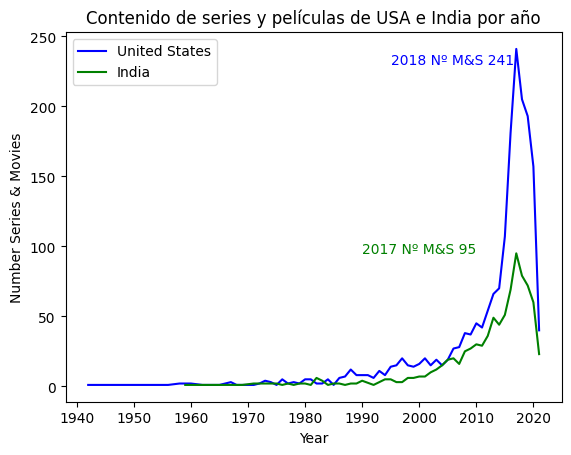

In [26]:
# Filtrar las filas para obtener solo las películas/series de India
india = df_clean[df_clean['country'] == 'India']

# Agrupar por año y contar el número de películas/series por cada año
usa_counts_by_year = usa.groupby('release_year').size()
india_counts_by_year = india.groupby('release_year').size()

# Graficar las dos líneas (USA e India) en el mismo gráfico
plt.plot(usa_counts_by_year.index, usa_counts_by_year.values, label='United States', color='blue')
plt.plot(india_counts_by_year.index, india_counts_by_year.values, label='India', color='green')

# Añadir título y etiquetas
plt.title('Contenido de series y películas de USA e India por año')
plt.ylabel('Number Series & Movies')
plt.xlabel('Year')

# Añadir texto al gráfico
plt.text(1995, 230, '2018 Nº M&S 241', color='blue')  # Ejemplo de texto en el gráfico
plt.text(1990, 95, '2017 Nº M&S 95', color='Green')
# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

In [27]:
# Supongamos que tienes el DataFrame 'df' con columnas 'country' y 'release_year'
# Filtrar los datos que te interesan (por ejemplo, si necesitas solo Estados Unidos e India)
df_filtered = df_clean[df_clean['country'].isin(['United States', 'India', 'United Kingdom', 'Canada', 'Spain' ])]
# Crear una tabla dinámica (pivot table) con 'country' como índice y 'release_year' como columnas
pivot_df = df_filtered.pivot_table(index='country', columns='release_year', aggfunc='size', fill_value=0)
# Añadir una columna 'Total' que sea la suma de las películas/series por país
#pivot_df['Total'] = pivot_df.sum(axis=1)

# Mostrar el DataFrame resultante
pivot_df


release_year,1942,1945,1946,1947,1954,1955,1956,1958,1959,1960,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
country,,,,,,,,,,,,,,,,,,,,,
Canada,0,0,0,0,0,0,0,0,0,0,...,0,0,7,9,15,22,21,10,13,0
India,0,0,0,0,0,0,0,0,1,0,...,36,49,44,51,69,95,79,72,60,23
Spain,0,0,0,0,0,0,0,0,0,0,...,0,0,0,8,15,15,22,12,11,7
United Kingdom,0,0,0,0,0,0,0,0,0,0,...,4,4,15,17,26,29,26,13,19,5
United States,1,1,1,1,1,1,1,2,0,2,...,54,66,70,107,181,241,205,193,157,40


In [28]:
pivot_df_t = pivot_df.T

# Mostrar el DataFrame traspuesto
pivot_df_t

country,Canada,India,Spain,United Kingdom,United States
release_year,,,,,
1942,0,0,0,0,1
1945,0,0,0,0,1
1946,0,0,0,0,1
1947,0,0,0,0,1
1954,0,0,0,0,1
...,...,...,...,...,...
2017,22,95,15,29,241
2018,21,79,22,26,205
2019,10,72,12,13,193


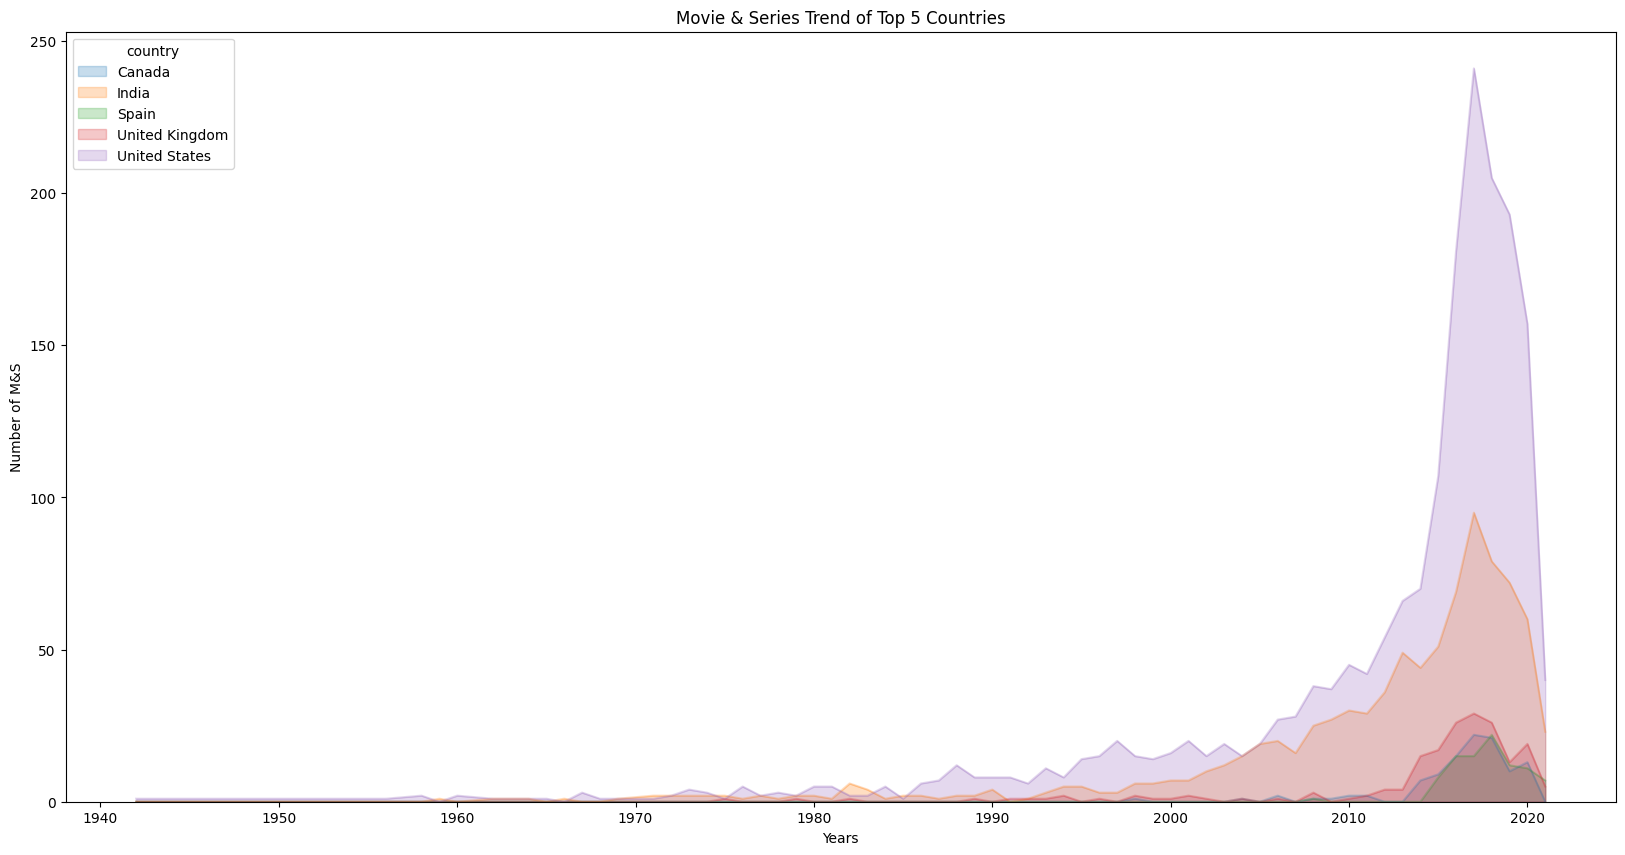

In [29]:
pivot_df_t.plot(kind='area', 
             alpha=0.25,  # 0 - 1, default value alpha = 0.5
             stacked=False,
             figsize=(20, 10))

plt.title('Movie & Series Trend of Top 5 Countries')
plt.ylabel('Number of M&S')
plt.xlabel('Years')

plt.show()

Text(0.5, 0, 'Years')

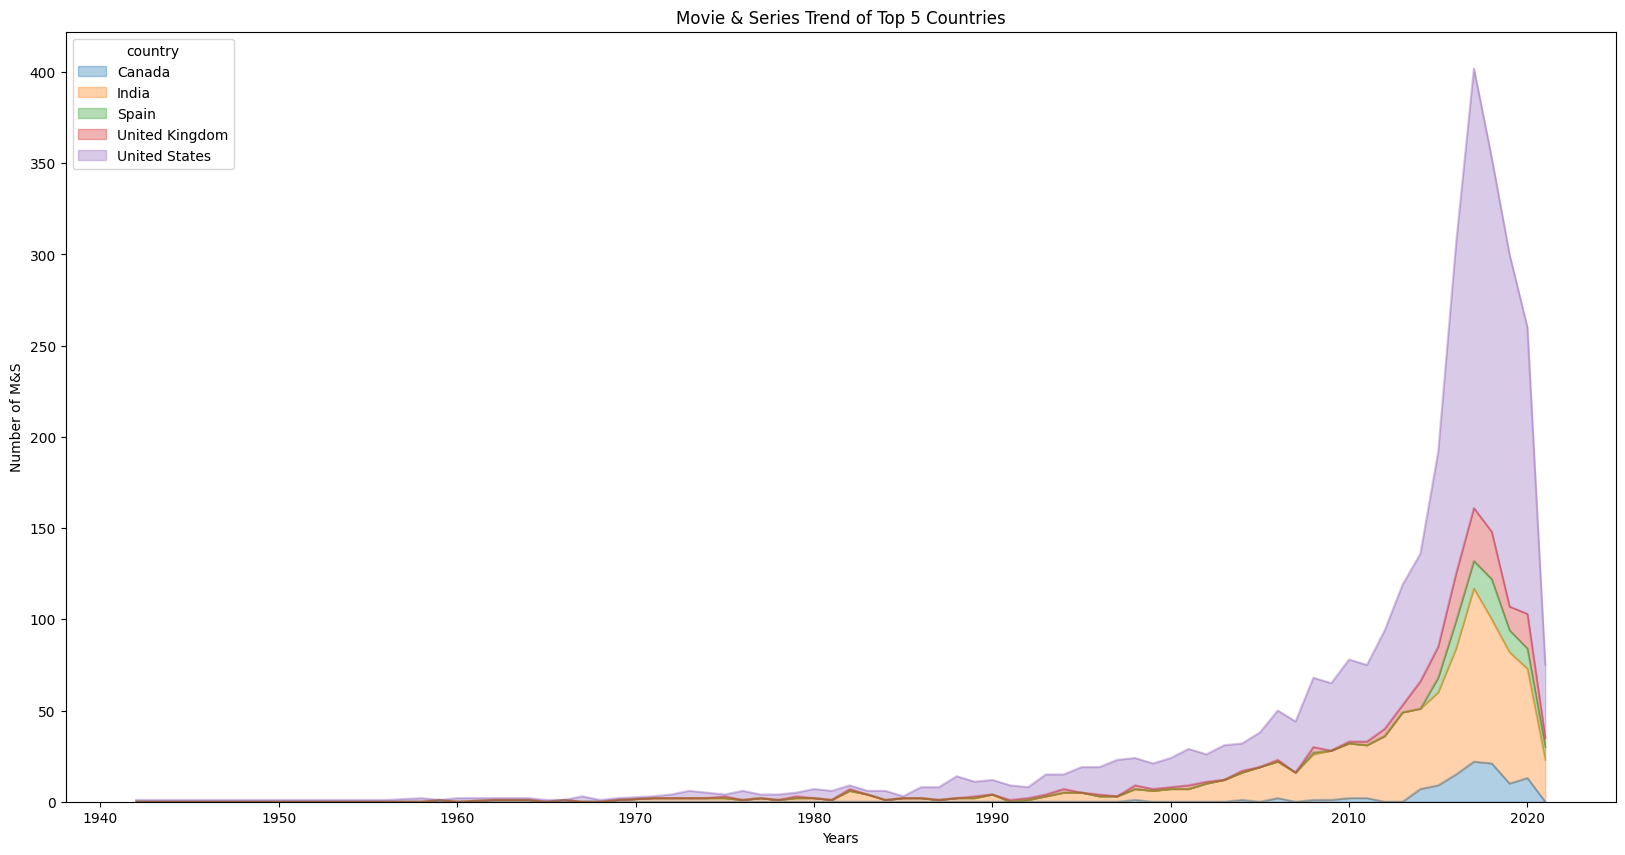

In [30]:
ax = pivot_df_t.plot(kind='area', alpha=0.35, figsize=(20, 10))

ax.set_title('Movie & Series Trend of Top 5 Countries')
ax.set_ylabel('Number of M&S')
ax.set_xlabel('Years')

In [31]:
print(pivot_df.columns)

Index([1942, 1945, 1946, 1947, 1954, 1955, 1956, 1958, 1959, 1960, 1962, 1964,
       1965, 1966, 1967, 1968, 1969, 1971, 1972, 1973, 1974, 1975, 1976, 1977,
       1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989,
       1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021],
      dtype='int64', name='release_year')


In [32]:
# No filtrar por países específicos, incluir todos los países
df_filtered = df_clean  # No hay filtrado aquí, se toman todos los países

# Crear una tabla dinámica (pivot table) con 'country' como índice y 'release_year' como columnas
pivot_df = df_filtered.pivot_table(index='country', columns='release_year', aggfunc='size', fill_value=0)

# Añadir una columna 'Total' que sea la suma de las películas/series por país
pivot_df['Total'] = pivot_df.sum(axis=1)

# Ordenar el DataFrame por la columna 'Total' de mayor a menor
pivot_df = pivot_df.sort_values(by='Total', ascending=False)

# Mostrar el DataFrame resultante
pivot_df

release_year,1942,1944,1945,1946,1947,1954,1955,1956,1958,1959,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Total
country,,,,,,,,,,,,,,,,,,,,,
United States,1,0,1,1,1,1,1,1,2,0,...,66,70,107,181,241,205,193,157,40,1849
India,0,0,0,0,0,0,0,0,0,1,...,49,44,51,69,95,79,72,60,23,875
United Kingdom,0,0,0,0,0,0,0,0,0,0,...,4,15,17,26,29,26,13,19,5,183
Canada,0,0,0,0,0,0,0,0,0,0,...,0,7,9,15,22,21,10,13,0,107
Spain,0,0,0,0,0,0,0,0,0,0,...,0,0,8,15,15,22,12,11,7,91
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Indonesia, United Kingdom",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
"Indonesia, South Korea, Singapore",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
"Indonesia, Netherlands",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [33]:

pivot_df.columns = pivot_df.columns.astype(str).str.strip()

# Ahora intenta acceder a '2020'
df_top2020 = pivot_df['2020'].head(10)
df_top2020

country
United States     157
India              60
United Kingdom     19
Canada             13
Spain              11
Egypt               1
Nigeria            12
Japan               7
Turkey              2
Indonesia          14
Name: 2020, dtype: int64

In [34]:
# np.histogram returns 2 values
count, bin_edges = np.histogram(df_top2020)

print(count) # frequency count
print(bin_edges) # bin ranges, default = 10 bins

[7 1 0 1 0 0 0 0 0 1]
[  1.   16.6  32.2  47.8  63.4  79.   94.6 110.2 125.8 141.4 157. ]


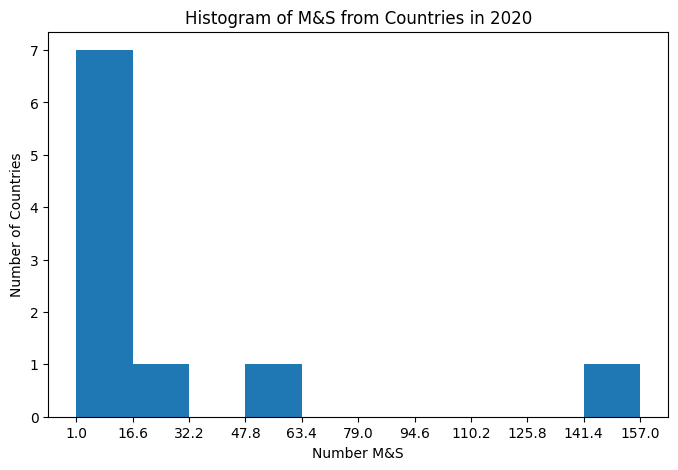

In [35]:
# 'bin_edges' is a list of bin intervals
count, bin_edges = np.histogram(df_top2020)
df_top2020.plot(kind='hist', figsize=(8, 5), xticks=bin_edges)
# add a title to the histogram
plt.title('Histogram of M&S from Countries in 2020')
# add y-label
plt.ylabel('Number of Countries')
# add x-label
plt.xlabel('Number M&S')

plt.show()

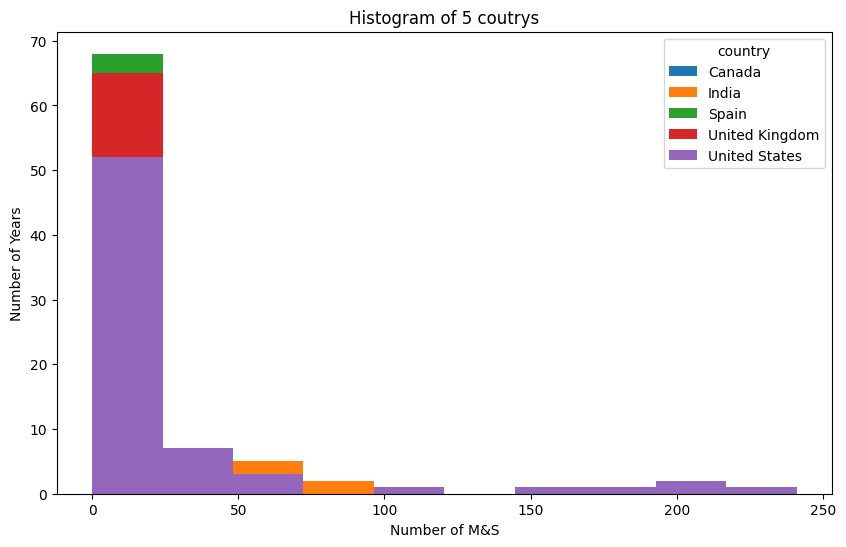

In [36]:
# generate histogram
pivot_df_t.plot(kind='hist', figsize=(10, 6))

plt.title('Histogram of 5 coutrys')
plt.ylabel('Number of Years')
plt.xlabel('Number of M&S')

plt.show()

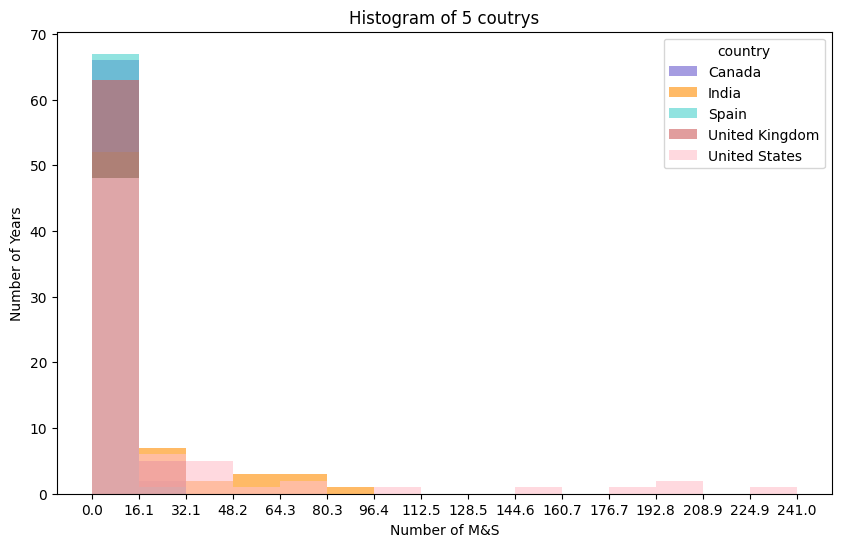

In [37]:
# let's get the x-tick values
count, bin_edges = np.histogram(pivot_df_t, 15)

# un-stacked histogram
pivot_df_t.plot(kind ='hist', 
          figsize=(10, 6),
          bins=15,
          alpha=0.6,
          xticks=bin_edges,
          color = ['slateblue', 'darkorange', 'mediumturquoise', 'indianred', 'pink']
          )

plt.title('Histogram of 5 coutrys')
plt.ylabel('Number of Years')
plt.xlabel('Number of M&S')

plt.show()

In [38]:
# group countries by continents and apply sum() function 
# Agrupar por 'country' y luego sumar
df_country = pivot_df.groupby('country').sum()

# Ver el tipo de objeto devuelto por groupby
print(type(pivot_df.groupby('country')))

# Ordenar por la columna 'duration' de mayor a menor
df_country_sorted = df_country.sort_values(by='Total', ascending=False)

Top_5 = df_country_sorted.head(5)
Top_5

<class 'pandas.core.groupby.generic.DataFrameGroupBy'>


release_year,1942,1944,1945,1946,1947,1954,1955,1956,1958,1959,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,Total
country,,,,,,,,,,,,,,,,,,,,,
United States,1,0,1,1,1,1,1,1,2,0,...,66,70,107,181,241,205,193,157,40,1849
India,0,0,0,0,0,0,0,0,0,1,...,49,44,51,69,95,79,72,60,23,875
United Kingdom,0,0,0,0,0,0,0,0,0,0,...,4,15,17,26,29,26,13,19,5,183
Canada,0,0,0,0,0,0,0,0,0,0,...,0,7,9,15,22,21,10,13,0,107
Spain,0,0,0,0,0,0,0,0,0,0,...,0,0,8,15,15,22,12,11,7,91


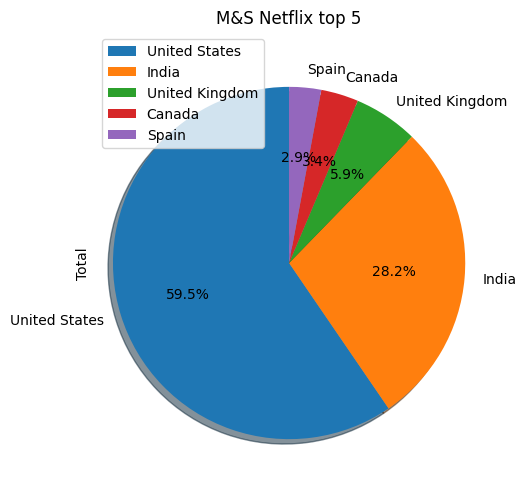

In [39]:
Top_5['Total'].plot(kind='pie',
                            figsize=(5, 6),
                            autopct='%1.1f%%', # add in percentages
                            startangle=90,     # start angle 90° (Africa)
                            shadow=True,       # add shadow      
                            )

plt.title('M&S Netflix top 5')
plt.axis('equal') # Sets the pie chart to look like a circle.
plt.legend(labels=df_country_sorted.index, loc='upper left') 


plt.show()

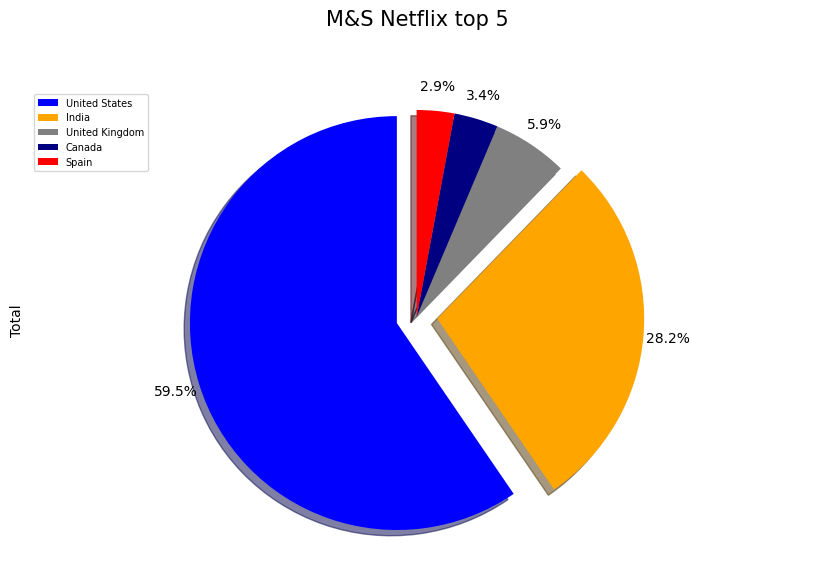

In [40]:
colors_list = ['blue', 'orange', 'grey', 'navy', 'red']
explode_list = [0.1, 0.1, 0, 0, 0] # ratio for each continent with which to offset each wedge.

Top_5['Total'].plot(kind='pie',
                            figsize=(10, 6),
                            autopct='%1.1f%%', 
                            startangle=90,    
                            shadow=True,       
                            labels=None,         # turn off labels on pie chart
                            pctdistance=1.12,    # the ratio between the center of each pie slice and the start of the text generated by autopct 
                            colors=colors_list,  # add custom colors
                            explode=explode_list # 'explode' lowest 3 continents
                            )

# scale the title up by 12% to match pctdistance
plt.title('M&S Netflix top 5', y=1.12, fontsize = 15) 

plt.axis('equal') 

# add legend
plt.legend(labels=df_country_sorted.index, loc='upper left', fontsize=7) 

plt.show()

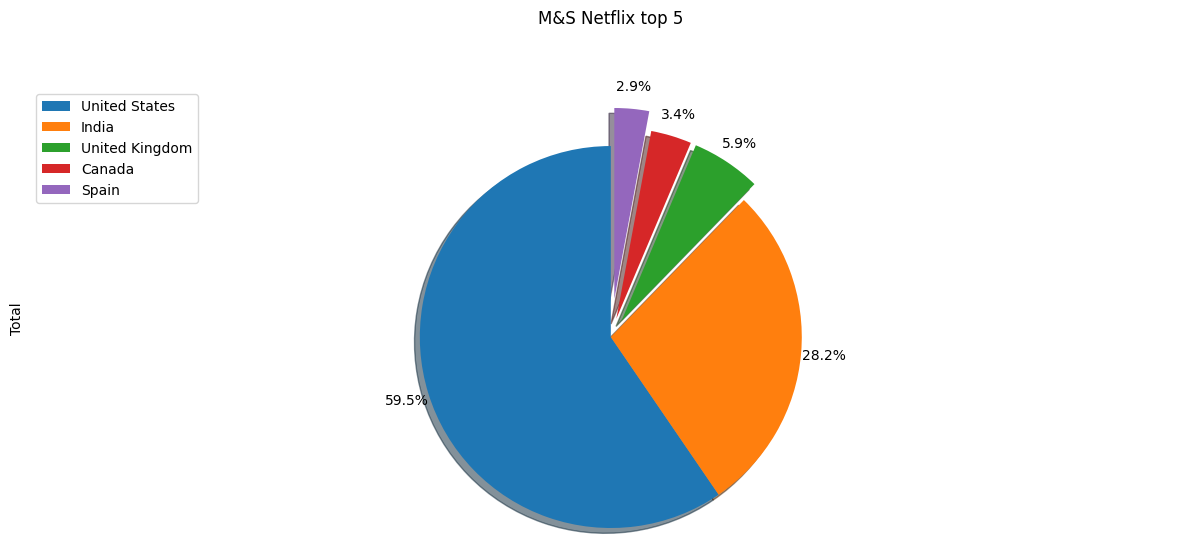

In [42]:
explode_list = [0, 0, 0.1, 0.1, 0.2] # ratio for each continent with which to offset each wedge.

Top_5['Total'].plot(kind='pie',
                            figsize=(15, 6),
                            autopct='%1.1f%%', 
                            startangle=90,    
                            shadow=True,       
                            labels=None,         # turn off labels on pie chart
                            pctdistance=1.12,    # the ratio between the center of each pie slice and the start of the text generated by autopct 
                            explode=explode_list # 'explode' lowest 3 continents
                            )

# scale the title up by 12% to match pctdistance
plt.title('M&S Netflix top 5', y=1.12) 

plt.axis('equal') 

# add legend
plt.legend(labels=df_country_sorted.index, loc='upper left') 

plt.show()

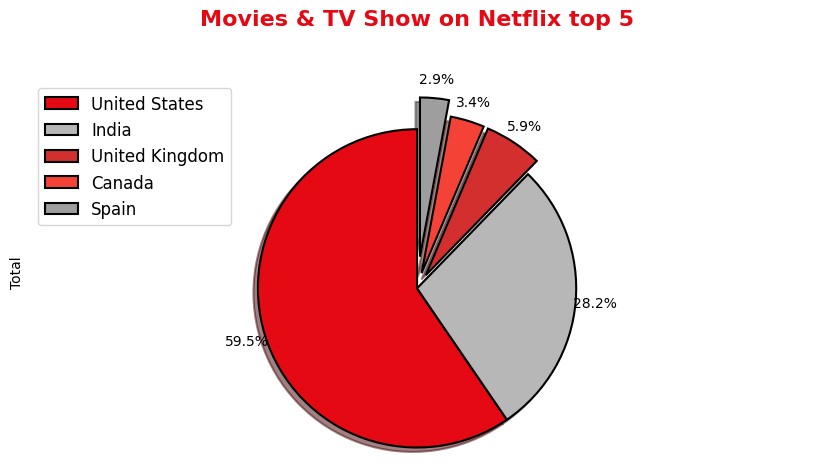

In [44]:
import matplotlib.pyplot as plt

# Colores inspirados en Netflix (rojo y negro)
netflix_colors = ['#E50914', '#B7B7B7', '#D32F2F', '#F44336', '#9E9E9E']

# Explode list
explode_list = [0, 0, 0.1, 0.1, 0.2]  # ratio for each continent with which to offset each wedge.

# Crear el gráfico de torta
Top_5['Total'].plot(kind='pie',
                    figsize=(10, 5),
                    autopct='%1.1f%%', 
                    startangle=90,    
                    shadow=True,       
                    labels=None,  # turn off labels on pie chart
                    pctdistance=1.12,  # the ratio between the center of each pie slice and the start of the text generated by autopct 
                    explode=explode_list,  # 'explode' lowest 3 continents
                    colors=netflix_colors,  # Usar los colores inspirados en Netflix
                    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}  # Añadir borde negro a las rebanadas
                    )

# Ajustar el título
plt.title('Movies & TV Show on Netflix top 5', y=1.12, fontsize=16, fontweight='bold', color='#E50914')

# Asegurarse de que el gráfico sea circular
plt.axis('equal')

# Añadir leyenda
plt.legend(labels=df_country_sorted.index, loc='upper left', fontsize=12)

# Mostrar el gráfico
plt.show()

In [45]:
# to get a dataframe, place extra square brackets around 'Japan'.
# Filtrar el DataFrame donde la columna 'country' sea 'United States'
USA_df = pivot_df_t.loc[:, 'United States']

# Mostrar el DataFrame filtrado
USA_df

release_year
1942      1
1945      1
1946      1
1947      1
1954      1
       ... 
2017    241
2018    205
2019    193
2020    157
2021     40
Name: United States, Length: 68, dtype: int64

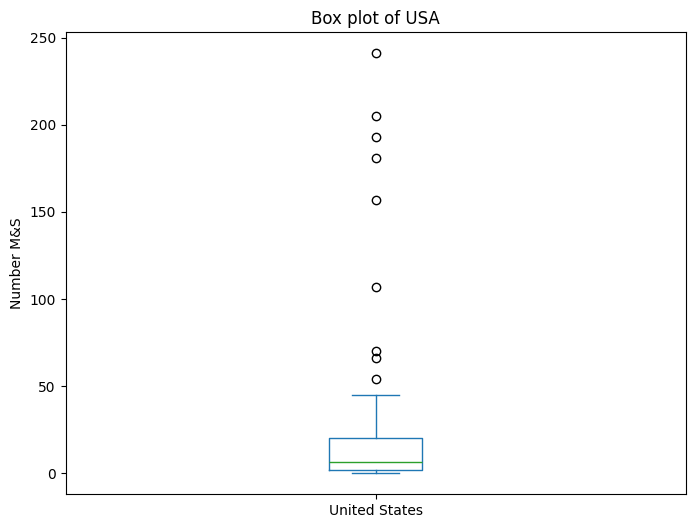

In [46]:
USA_df.plot(kind='box', figsize=(8, 6))

plt.title('Box plot of USA')
plt.ylabel('Number M&S')

plt.show()

In [47]:
USA_df.describe().round(2)

count     68.00
mean      27.19
std       52.08
min        0.00
25%        1.75
50%        6.50
75%       20.00
max      241.00
Name: United States, dtype: float64

In [48]:
df_SI = pivot_df_t.loc[:, ['Spain', 'India']]
df_SI.head()

country,Spain,India
release_year,,
1942,0,0
1945,0,0
1946,0,0
1947,0,0
1954,0,0


In [49]:
df_SI.describe().round(2)

country,Spain,India
count,68.00,68.00
mean,1.34,12.87
std,4.22,21.60
min,0.00,0.00
25%,0.00,1.00
50%,0.00,2.00
75%,0.00,15.25
max,22.00,95.00


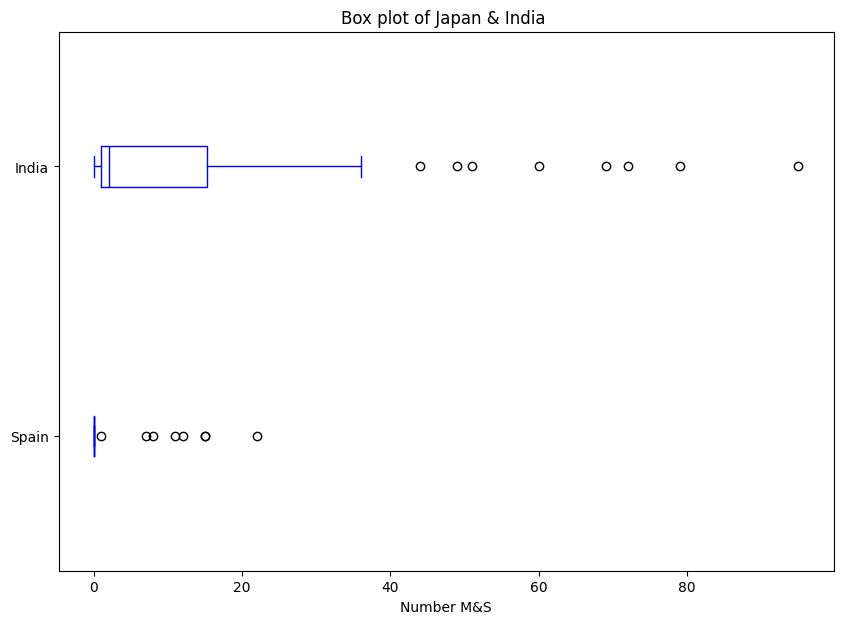

In [50]:
df_SI.plot(kind='box', figsize=(10, 7),color='blue', vert=False)

plt.title('Box plot of Japan & India ')
plt.xlabel('Number M&S')

plt.show()

In [51]:
# cast the Years (the index) to type int
pivot_df_t.index = map(int, pivot_df_t.index)
# let's label the index. This will automatically be the column name when we reset the index
pivot_df_t.index.name = 'release_year'

# reset index to bring the Year in as a column
pivot_df_t.reset_index(inplace=True)

# view the changes
pivot_df_t.head()

country,release_year,Canada,India,Spain,United Kingdom,United States
0,1942,0,0,0,0,1
1,1945,0,0,0,0,1
2,1946,0,0,0,0,1
3,1947,0,0,0,0,1
4,1954,0,0,0,0,1


In [52]:
# normalize United States data
norm_usa = (pivot_df_t['United States'] - pivot_df_t['United States'].min()) / (pivot_df_t['United States'].max() - pivot_df_t['United States'].min())

# normalize India data
norm_india = (pivot_df_t['India'] - pivot_df_t['India'].min()) / (pivot_df_t['India'].max() - pivot_df_t['India'].min())

# normalize United Kingdom data
norm_uk = (pivot_df_t['United Kingdom'] - pivot_df_t['United Kingdom'].min()) / (pivot_df_t['United Kingdom'].max() - pivot_df_t['United Kingdom'].min())

# normalize Spain data
norm_sp = (pivot_df_t['Spain'] - pivot_df_t['Spain'].min()) / (pivot_df_t['Spain'].max() - pivot_df_t['Spain'].min())

# normalize Canada data
norm_cd = (pivot_df_t['Canada'] - pivot_df_t['Canada'].min()) / (pivot_df_t['Canada'].max() - pivot_df_t['Canada'].min())

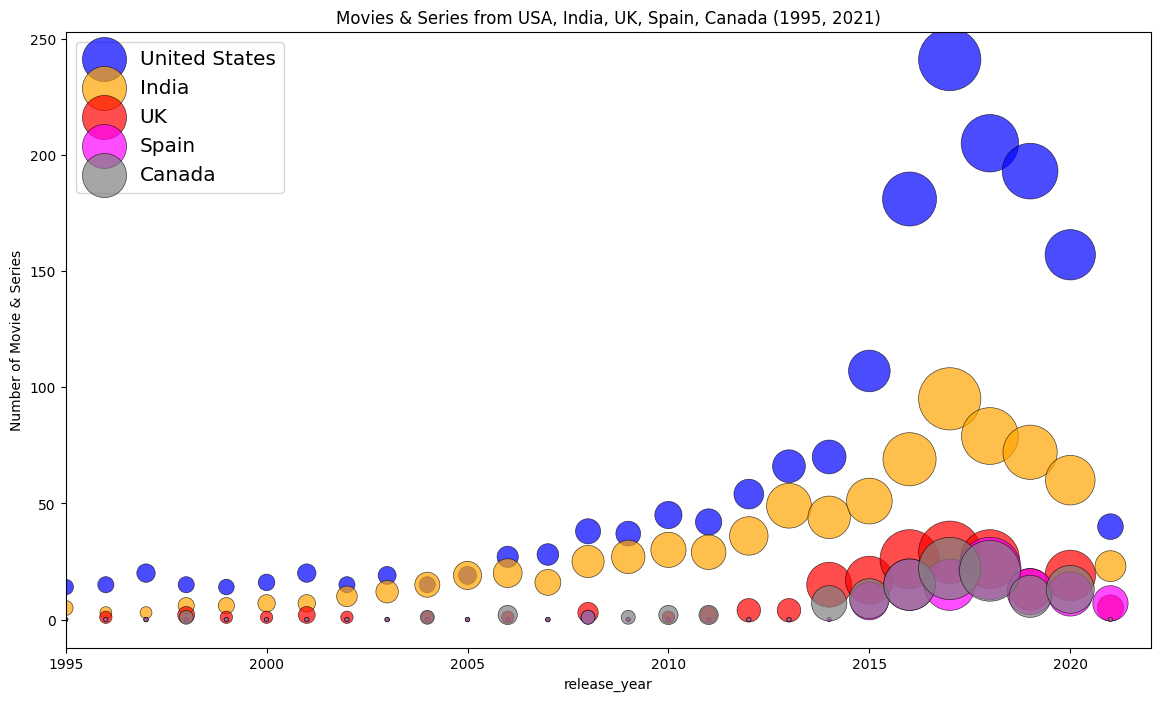

In [53]:
# USA
ax0 = pivot_df_t.plot(kind='scatter',
                    x='release_year',
                    y='United States',
                    figsize=(14, 8),
                    alpha=0.7,  # transparency
                    color='Blue',
                    s=norm_usa * 2000 + 10,  # pass in weights 
                    xlim=(1995, 2022),
                    edgecolor='black',
                    linewidth=0.5,
                    legend=False
                    )

# India
ax1 = pivot_df_t.plot(kind='scatter',
                    x='release_year',
                    y='India',
                    alpha=0.7,
                    color="Orange",
                    s=norm_india * 2000 + 10,
                    ax=ax0,
                    edgecolor='black',
                    linewidth=0.5,
                    legend=False
                    )

# United Kingdom
ax2 = pivot_df_t.plot(kind='scatter',
                    x='release_year',
                    y='United Kingdom',
                    alpha=0.7,
                    color="Red",
                    s=norm_uk * 2000 + 10,
                    ax=ax0,
                    edgecolor='black',
                    linewidth=0.5,
                    legend=False
                    )

# Spain
ax3 = pivot_df_t.plot(kind='scatter',
                    x='release_year',
                    y='Spain',
                    alpha=0.7,
                    color="Magenta",
                    s=norm_sp * 2000 + 10,
                    ax=ax0,
                    edgecolor='black',
                    linewidth=0.5,
                    legend=False
                    )                   

# Canada
ax4 = pivot_df_t.plot(kind='scatter',
                    x='release_year',
                    y='Canada',
                    alpha=0.7,
                    color="Grey",
                    s=norm_cd * 2000 + 10,
                    ax=ax0,
                    edgecolor='black',
                    linewidth=0.5,
                    legend=False
                    )
ax0.set_ylabel('Number of Movie & Series')
ax0.set_title('Movies & Series from USA, India, UK, Spain, Canada (1995, 2021)')
ax0.legend(['United States', 'India', 'UK', 'Spain', 'Canada'], loc='upper left', fontsize='x-large')

In [54]:
# Eliminar filas vacías
df_clean = df_clean.dropna(how='all')

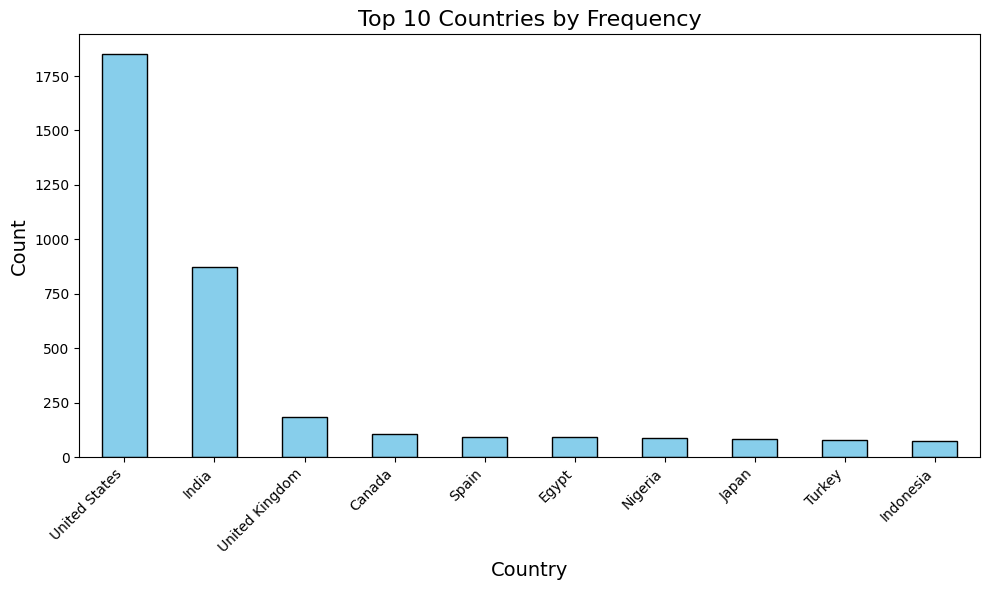

In [69]:
# Contar las ocurrencias de cada país en la columna 'country'
country_counts = df_clean['country'].value_counts()

# Seleccionar solo los 10 países más frecuentes
top_10_countries = country_counts.head(10)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))  # Tamaño del gráfico
top_10_countries.plot(kind='bar', color='skyblue', edgecolor='black')  # Gráfico de barras

# Añadir etiquetas y título
plt.title('Top 10 Countries by Frequency', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Count', fontsize=14)

# Rotar las etiquetas del eje X para mayor claridad si los nombres de los países son largos
plt.xticks(rotation=45, ha='right')

# Mejorar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

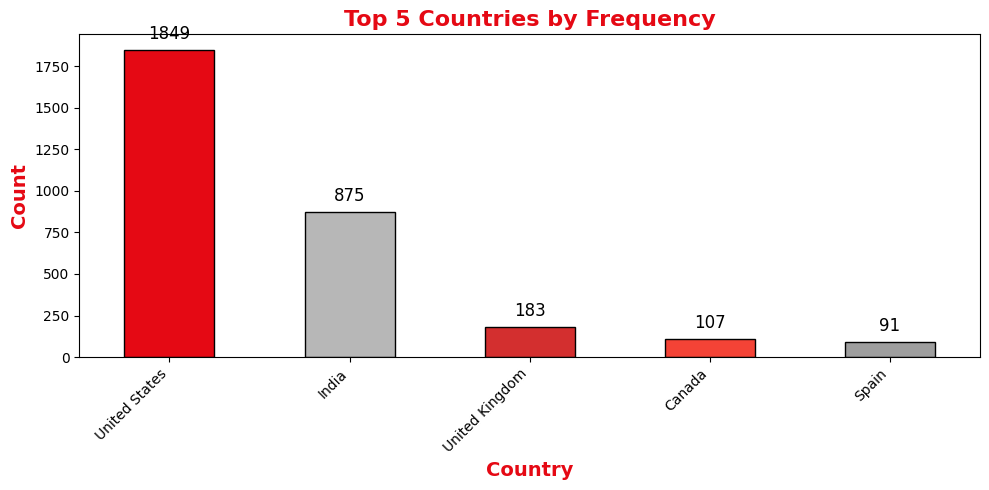

In [58]:
import matplotlib.pyplot as plt

# Colores inspirados en Netflix (rojo y gris)
netflix_colors = ['#E50914', '#B7B7B7', '#D32F2F', '#F44336', '#9E9E9E', '#B7B7B7', '#D32F2F', '#F44336', '#E50914', '#9E9E9E']

# Contar las ocurrencias de cada país en la columna 'country'
country_counts = df_clean['country'].value_counts()

# Seleccionar solo los 10 países más frecuentes
top_10_countries = country_counts.head(5)

# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 5))  # Tamaño del gráfico
top_10_countries.plot(kind='bar', color=netflix_colors, edgecolor='black', ax=ax)  # Gráfico de barras con colores personalizados

# Añadir etiquetas y título
ax.set_title('Top 5 Countries by Frequency', fontsize=16, fontweight='bold', color='#E50914')  # Título en color Netflix (rojo)
ax.set_xlabel('Country', fontsize=14, fontweight='bold', color='#E50914')  # Etiqueta del eje X en rojo
ax.set_ylabel('Count', fontsize=14, fontweight='bold', color='#E50914')  # Etiqueta del eje Y en rojo

# Rotar las etiquetas del eje X para mayor claridad si los nombres de los países son largos
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Mostrar los números de frecuencia encima de las barras utilizando ax.containers
for container in ax.containers:
    ax.bar_label(container, fontsize=12, color='black', padding=5)

# Mejorar el diseño y mostrar el gráfico
plt.tight_layout()

# Mostrar el gráfico
plt.show()


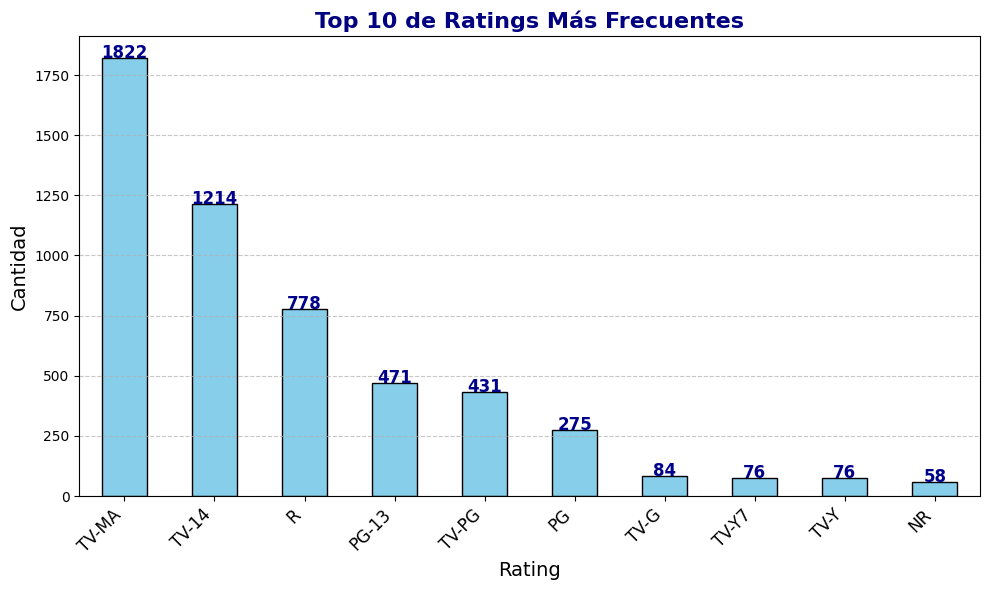

In [72]:
# Obtener las 10 calificaciones más frecuentes
top_10_ratings = df_clean['rating'].value_counts().head(10)

# Crear el gráfico de barras con estilo mejorado
plt.figure(figsize=(10, 6))  # Tamaño más grande del gráfico
top_10_ratings.plot(kind='bar', color='skyblue', edgecolor='black')

# Títulos y etiquetas
plt.title('Top 10 de Ratings Más Frecuentes', fontsize=16, fontweight='bold', color='navy')
plt.xlabel('Rating', fontsize=14)
plt.ylabel('Cantidad', fontsize=14)

# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45, ha='right', fontsize=12)

# Añadir las etiquetas de los valores sobre las barras
for i, value in enumerate(top_10_ratings):
    plt.text(i, value + 0.1, str(value), ha='center', fontsize=12, fontweight='bold', color='darkblue')

# Mostrar grid para facilitar la lectura de valores
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()  # Ajustar los márgenes
plt.show()

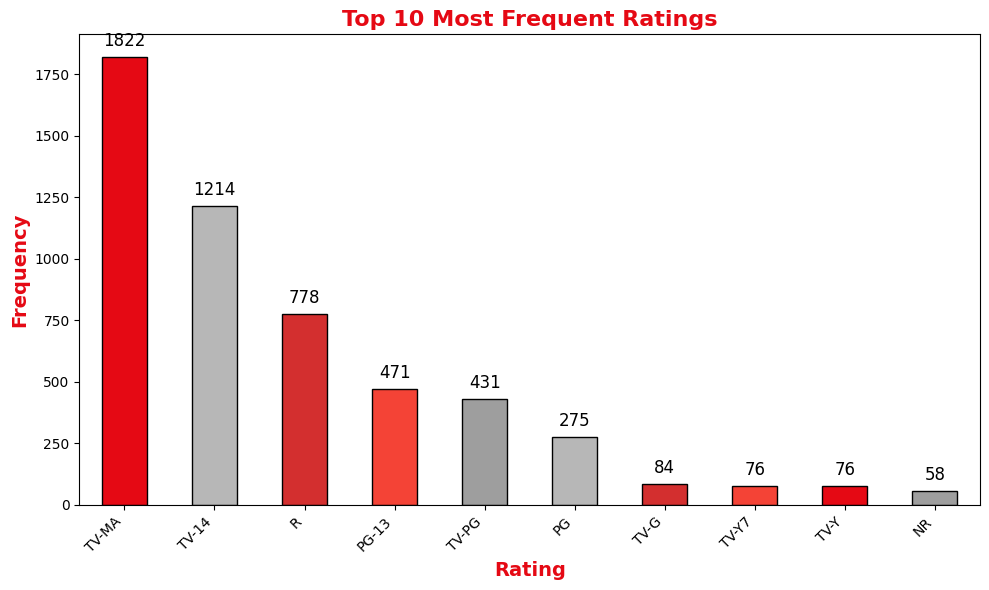

In [61]:
import matplotlib.pyplot as plt

# Obtener las 10 calificaciones más frecuentes
top_10_ratings = df_clean['rating'].value_counts().head(10)

# Colores inspirados en Netflix (rojo y gris)
netflix_colors = ['#E50914', '#B7B7B7', '#D32F2F', '#F44336', '#9E9E9E', '#B7B7B7', '#D32F2F', '#F44336', '#E50914', '#9E9E9E']

# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(10, 6))  # Tamaño del gráfico
top_10_ratings.plot(kind='bar', color=netflix_colors, edgecolor='black', ax=ax)  # Gráfico de barras con colores personalizados

# Añadir etiquetas y título
ax.set_title('Top 10 Most Frequent Ratings', fontsize=16, fontweight='bold', color='#E50914')  # Título en color Netflix (rojo)
ax.set_xlabel('Rating', fontsize=14, fontweight='bold', color='#E50914')  # Etiqueta del eje X en rojo
ax.set_ylabel('Frequency', fontsize=14, fontweight='bold', color='#E50914')  # Etiqueta del eje Y en rojo

# Rotar las etiquetas del eje X para mayor claridad
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Mostrar los números de frecuencia encima de las barras utilizando ax.containers
for container in ax.containers:
    ax.bar_label(container, fontsize=12, color='black', padding=5)

# Mejorar el diseño y mostrar el gráfico
plt.tight_layout()

# Mostrar el gráfico
plt.show()


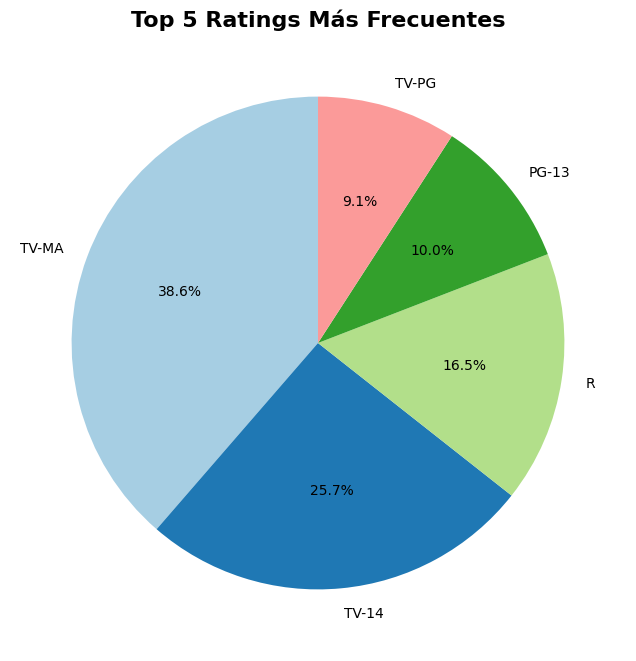

In [62]:
# Contar las 5 calificaciones más frecuentes
top_5_ratings = df_clean['rating'].value_counts().head(5)

# Crear el gráfico de pastel para las 5 calificaciones más frecuentes
plt.figure(figsize=(8, 8))
top_5_ratings.plot(kind='pie', autopct='%1.1f%%', colors=plt.cm.Paired.colors, startangle=90, legend=False)

# Título del gráfico
plt.title('Top 5 Ratings Más Frecuentes', fontsize=16, fontweight='bold')

# Mostrar el gráfico
plt.ylabel('')  # Eliminar la etiqueta en el eje y para una apariencia más limpia
plt.show()

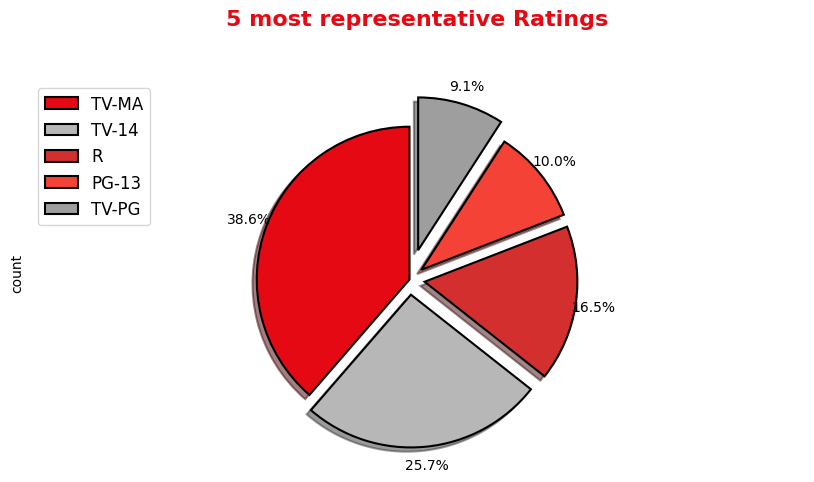

In [74]:
import matplotlib.pyplot as plt

# Contar las 5 calificaciones más frecuentes
top_5_ratings = df_clean['rating'].value_counts().head(5)

# Colores inspirados en Netflix (rojo y gris)
netflix_colors = ['#E50914', '#B7B7B7', '#D32F2F', '#F44336', '#9E9E9E']

# Explode list para destacar algunas secciones
explode_list = [0, 0.1, 0.1, 0.1, 0.2]  # Destacar algunas secciones

# Crear el gráfico de pastel para las 5 calificaciones más frecuentes
plt.figure(figsize=(10, 5))
top_5_ratings.plot(kind='pie',
                   autopct='%1.1f%%',  # Formato de los porcentajes
                   startangle=90,      # Iniciar el gráfico de pastel desde el ángulo correcto
                   shadow=True,        # Añadir sombra al gráfico
                   labels=None,        # Eliminar etiquetas internas
                   pctdistance=1.12,   # Distancia de los porcentajes con respecto al centro
                   explode=explode_list,  # Explosión de las porciones seleccionadas
                   colors=netflix_colors,  # Colores inspirados en Netflix
                   wedgeprops={'edgecolor': 'black', 'linewidth': 1.5}  # Borde negro en las rebanadas
                   )

# Ajustar el título
plt.title('5 most representative Ratings', y=1.12, fontsize=16, fontweight='bold', color='#E50914')

# Asegurarse de que el gráfico sea circular
plt.axis('equal')

# Añadir leyenda
plt.legend(labels=top_5_ratings.index, loc='upper left', fontsize=12)

# Mostrar el gráfico
plt.show()

In [67]:
expected_columns = len(df_clean.columns)
incorrect_rows = df_clean[df_clean.apply(lambda row: len(row) != expected_columns, axis=1)]
print(incorrect_rows)

Empty DataFrame
Columns: [show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description]
Index: []


In [73]:
# Leer filas 4903 y 4904 para ver si hay algún valor malformado
problematic_rows = df_clean.iloc[4902:4904]
problematic_rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4902,s8202,Movie,The Bad Education Movie,Elliot Hegarty,"Jack Whitehall, Joanna Scanlan, Iain Glen, Eth...",United Kingdom,"December 15, 2018",2015,TV-MA,87 min,Comedies,Britain's most ineffective but caring teacher ...
4903,s8204,Movie,The Bare-Footed Kid,Johnnie To,"Aaron Kwok, Lung Ti, Maggie Cheung, Chien-lien...",Hong Kong,"August 16, 2018",1993,TV-14,83 min,"Action & Adventure, International Movies","While working at a family friend's business, a..."


In [76]:
df_clean = df_clean.drop(columns=['show_id'])
df_clean

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
1,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
2,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
3,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
4,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
...,...,...,...,...,...,...,...,...,...,...,...
5331,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
5332,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
5333,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
5334,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [78]:
# Verificar el número de columnas en el DataFrame
num_columns = len(df_clean.columns)

# Comprobar si alguna fila tiene un número incorrecto de columnas
incorrect_rows = df_clean[df_clean.apply(lambda row: len(row) != num_columns, axis=1)]

# Mostrar las filas incorrectas (si hay alguna)
print(incorrect_rows)

Empty DataFrame
Columns: [type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description]
Index: []


In [83]:
# Eliminar las filas 4903 y 4904
df_clean = df_clean.drop(index=[4902, 4903])  # El índice es 0-based, por lo que 4903 sería el índice 4902 y 4904 el índice 4903

# Verificar que las filas fueron eliminadas
df_clean.iloc[4900:4910]  # Mostrar las filas cercanas a las eliminadas para verificar

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4900,Movie,The Autopsy of Jane Doe,André Øvredal,"Emile Hirsch, Brian Cox, Ophelia Lovibond, Mic...","United Kingdom, United States","December 30, 2018",2016,R,86 min,"Horror Movies, Independent Movies, Thrillers",A father-son team of small-town coroners perfo...
4901,Movie,The Bachelors,Kurt Voelker,"J.K. Simmons, Josh Wiggins, Julie Delpy, Odeya...",United States,"February 21, 2018",2017,TV-14,100 min,Dramas,"After the death of his wife, a teacher and his..."
4904,Movie,The Basement,"Brian M. Conley, Nathan Ives","Mischa Barton, Jackson Davis, Cayleb Long, Tra...",United States,"April 9, 2019",2018,TV-MA,89 min,"Horror Movies, Thrillers",Known for tortuous role-play with victims in h...
4905,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,"March 31, 2017",1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...
4906,Movie,The Bill Murray Stories: Life Lessons Learned ...,Tommy Avallone,"Tommy Avallone, Bill Murray, Joel Murray, Pete...",United States,"December 31, 2018",2018,TV-MA,72 min,Documentaries,This documentary highlights spontaneous encoun...
4907,Movie,The Black Room,Rolfe Kanefsky,"Natasha Henstridge, Lukas Hassel, Lin Shaye, D...",United States,"August 7, 2017",2016,TV-MA,95 min,Horror Movies,A couple's new dream home morphs into a nightm...
4908,Movie,The Blackcoat's Daughter,Osgood Perkins,"Emma Roberts, Kiernan Shipka, Lucy Boynton, La...","Canada, United States","May 18, 2019",2015,R,95 min,"Horror Movies, Independent Movies, Thrillers",When their parents fail to pick them up for wi...
4909,Movie,The Bleeder,Philippe Falardeau,"Liev Schreiber, Elisabeth Moss, Ron Perlman, N...",United States,"March 29, 2019",2016,R,98 min,"Dramas, Sports Movies","Husband. Father. Fighter. Meet Chuck Wepner, t..."
4910,TV Show,The Blue Planet: A Natural History of the Oceans,Alastair Fothergill,David Attenborough,United Kingdom,"October 10, 2015",2001,TV-G,1 Season,"British TV Shows, Docuseries, International TV...",David Attenborough narrates this definitive ex...
4911,Movie,The Book of Eli,"Albert Hughes, Allen Hughes","Denzel Washington, Gary Oldman, Mila Kunis, Ra...",United States,"July 1, 2019",2010,R,118 min,"Action & Adventure, Sci-Fi & Fantasy",Determined to protect a sacred text that promi...


In [84]:
# Guardar el archivo CSV actualizado
df_clean.to_csv('netflix_titles_clean.csv', index=False, encoding='utf-8')

## Conclusions & Business Implications
## Conclusiones e Implicaciones de Negocio

### Key Findings / Hallazgos Clave

**1. U.S. Dominance is real but the gap is closing**
The United States produces 59.6% of Netflix content. However, India and the UK 
show consistent year-over-year growth — signaling strong opportunities for 
local content investment in these markets.

**EE.UU. domina pero la brecha se está cerrando**
Estados Unidos produce el 59.6% del contenido de Netflix. Sin embargo, India y el 
Reino Unido muestran crecimiento consistente año tras año — señalando oportunidades 
de inversión en contenido local en estos mercados.

---

**2. Netflix's core audience is adults and teens**
TV-MA and TV-14 account for the majority of all ratings, confirming Netflix's 
primary focus on mature audiences. Family and children's content (TV-G, TV-Y) 
represents a significantly smaller share — a potential diversification opportunity.

**La audiencia principal de Netflix son adultos y adolescentes**
TV-MA y TV-14 representan la mayoría de las clasificaciones, confirmando el enfoque 
de Netflix en audiencias maduras. El contenido familiar e infantil representa 
una porción significativamente menor — una oportunidad de diversificación.

---

**3. Movies outnumber TV Shows, but series drive deeper engagement**
While movies dominate in volume, TV series generate higher actor and director 
recurrence — suggesting series are more strategic for talent retention and 
audience loyalty.

**Las películas superan en número a las series, pero las series generan mayor engagement**
Aunque las películas dominan en volumen, las series generan mayor recurrencia de 
actores y directores — sugiriendo que las series son más estratégicas para la 
retención de talento y la fidelidad de la audiencia.

---

### Strategic Recommendation / Recomendación Estratégica
A content executive could use this analysis to justify:
- Increasing investment in Indian and UK production partnerships
- Expanding family-friendly and children's content to capture underserved segments
- Prioritizing TV series for long-term audience retention strategy

Un ejecutivo de contenidos podría usar este análisis para justificar:
- Mayor inversión en alianzas de producción en India y Reino Unido
- Expansión de contenido familiar e infantil para capturar segmentos desatendidos
- Priorizar series de TV para estrategia de retención de audiencia a largo plazo